In [1]:
# setting up the connection so I can pull query results straight into pandas
# instead of exporting CSVs by hand every time I change a query

import getpass
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import URL, create_engine


sns.set_style("whitegrid")


password = os.environ.get("AIRBNB_DB_PASSWORD") or getpass.getpass(
    "PostgreSQL password: "
)

connection_url = URL.create(
    drivername="postgresql+psycopg",
    username="postgres",
    password=password,
    host="127.0.0.1",
    port=5432,
    database="airbnb",
)

engine = create_engine(connection_url)

print("Connected")

Connected


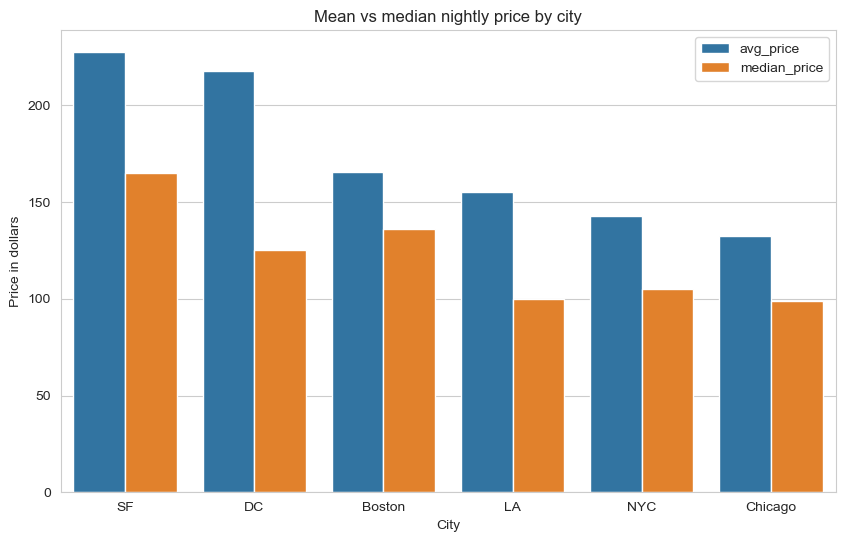

      city  avg_price  median_price
0       SF     227.37         165.0
1       DC     217.93         125.0
2   Boston     165.63         136.0
3       LA     155.39         100.0
4      NYC     143.02         105.0
5  Chicago     132.48          99.0


In [2]:
# this is the chart that justifies the whole project. the gap between the two
# bars is how much the average overstates what a normal listing costs

query = """
SELECT
    city,
    ROUND(AVG(EXP(log_price))::numeric, 2) AS avg_price,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EXP(log_price))::numeric
    , 2) AS median_price
FROM airbnb_data
GROUP BY city
ORDER BY avg_price DESC;
"""

prices = pd.read_sql(query, engine)

# seaborn wants one row per bar, so I reshape from two price columns into one
prices_long = prices.melt(
    id_vars="city",
    value_vars=["avg_price", "median_price"],
    var_name="measure",
    value_name="price"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=prices_long, x="city", y="price", hue="measure")
plt.title("Mean vs median nightly price by city")
plt.xlabel("City")
plt.ylabel("Price in dollars")
plt.legend(title="")
plt.show()

print(prices)

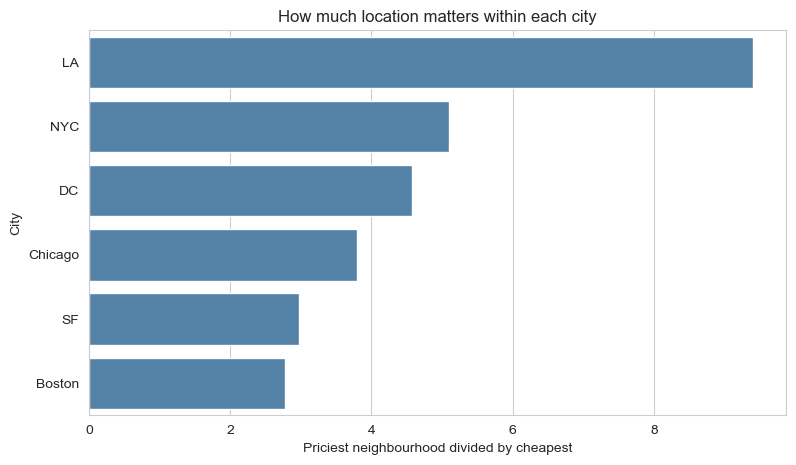

      city  spread_ratio
0       LA          9.40
1      NYC          5.10
2       DC          4.57
3  Chicago          3.80
4       SF          2.97
5   Boston          2.77


In [3]:
# how much does neighbourhood matter inside each city
# LA is the widest, SF is nearly the narrowest even though it is the priciest

query = """
WITH neighbourhood_prices AS (
    SELECT
        city,
        neighbourhood,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EXP(log_price)) AS median_price
    FROM airbnb_data
    WHERE neighbourhood IS NOT NULL
    GROUP BY city, neighbourhood
    HAVING COUNT(*) >= 30
)
SELECT
    city,
    ROUND((MAX(median_price) / MIN(median_price))::numeric, 2) AS spread_ratio
FROM neighbourhood_prices
GROUP BY city
ORDER BY spread_ratio DESC;
"""

spread = pd.read_sql(query, engine)

plt.figure(figsize=(9, 5))
sns.barplot(data=spread, x="spread_ratio", y="city", color="steelblue")
plt.title("How much location matters within each city")
plt.xlabel("Priciest neighbourhood divided by cheapest")
plt.ylabel("City")
plt.show()

print(spread)

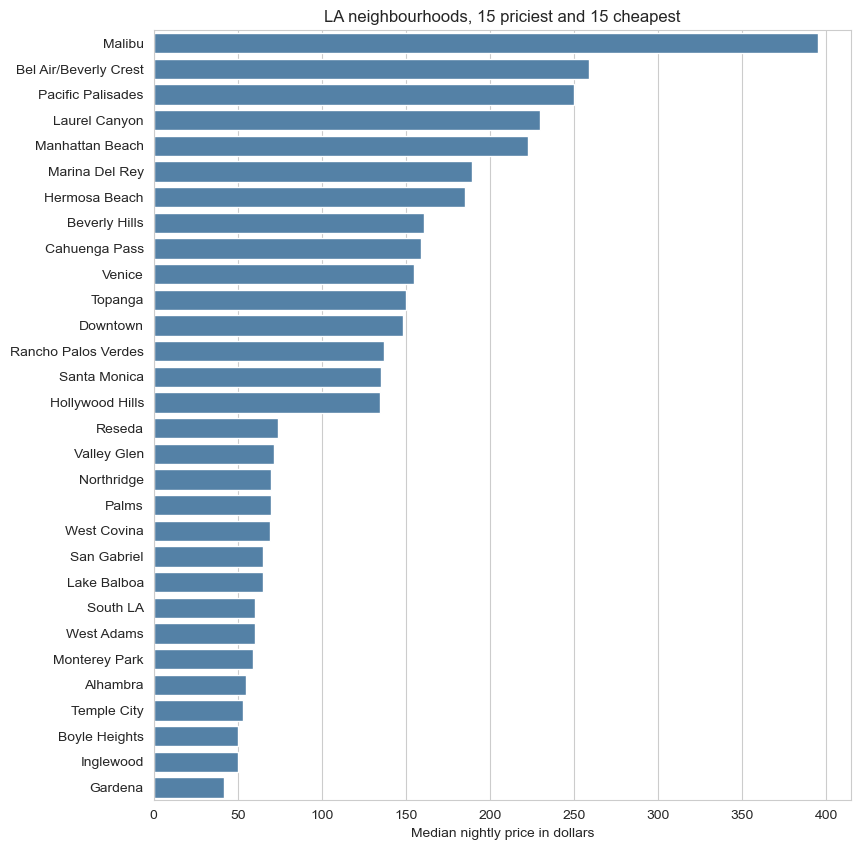

In [4]:
# LA top and bottom. cutting the middle out because 79 bars is unreadable

query = """
SELECT
    neighbourhood,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EXP(log_price))::numeric
    , 2) AS median_price
FROM airbnb_data
WHERE city = 'LA'
  AND neighbourhood IS NOT NULL
GROUP BY neighbourhood
HAVING COUNT(*) >= 30
ORDER BY median_price DESC;
"""

la = pd.read_sql(query, engine)

top_15 = la.head(15)
bottom_15 = la.tail(15)
ends = pd.concat([top_15, bottom_15])

plt.figure(figsize=(9, 10))
sns.barplot(data=ends, x="median_price", y="neighbourhood", color="steelblue")
plt.title("LA neighbourhoods, 15 priciest and 15 cheapest")
plt.xlabel("Median nightly price in dollars")
plt.ylabel("")
plt.show()

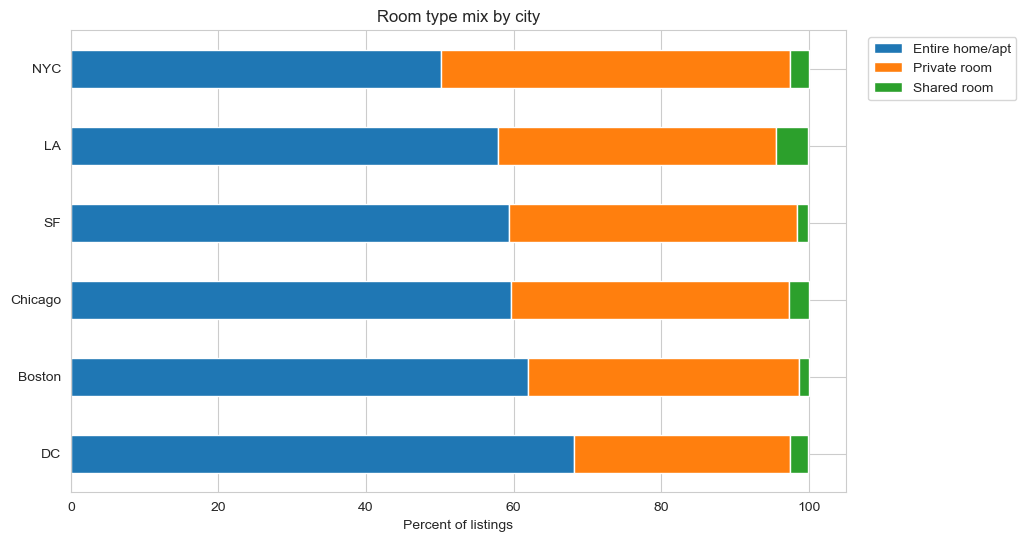

room_type  Entire home/apt  Private room  Shared room
city                                                 
DC                    68.2          29.3          2.4
Boston                61.9          36.8          1.3
Chicago               59.6          37.7          2.7
SF                    59.3          39.1          1.5
LA                    57.9          37.7          4.3
NYC                   50.2          47.3          2.5


In [5]:
# what people are actually renting. NYC has the shortest entire home bar,
# which is why its citywide median looked so low

query = """
SELECT
    city,
    room_type,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY city)
    , 1) AS pct_of_city
FROM airbnb_data
GROUP BY city, room_type;
"""

rooms = pd.read_sql(query, engine)

# pivoting so each city is one row and each room type is its own column,
# which is the shape pandas needs for a stacked bar
rooms_wide = rooms.pivot(index="city", columns="room_type", values="pct_of_city")
rooms_wide = rooms_wide.sort_values("Entire home/apt", ascending=False)

rooms_wide.plot(kind="barh", stacked=True, figsize=(10, 6))
plt.title("Room type mix by city")
plt.xlabel("Percent of listings")
plt.ylabel("")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

print(rooms_wide)

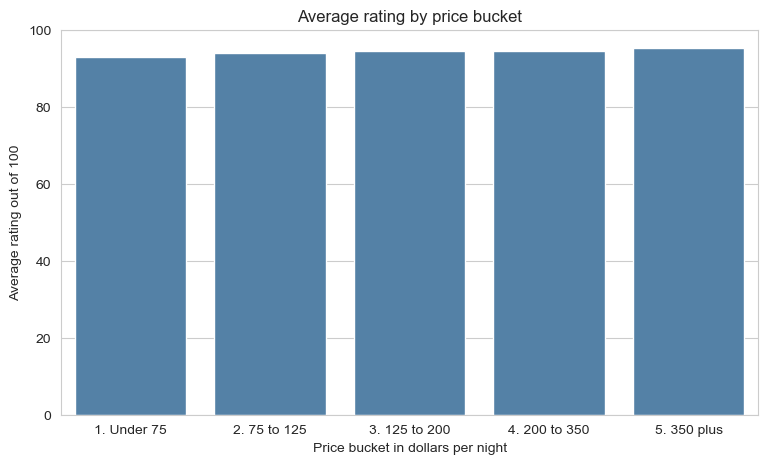

    price_bucket  avg_rating  avg_review_count
0    1. Under 75        93.1              23.8
1   2. 75 to 125        94.1              30.9
2  3. 125 to 200        94.5              29.2
3  4. 200 to 350        94.7              23.3
4    5. 350 plus        95.3              19.1


In [6]:
# does paying more get a better stay. the y axis runs the full 0 to 100 on
# purpose. zooming in would make a 2 point difference look like a big jump
# and that would oversell what is actually a pretty flat result

query = """
SELECT
    CASE
        WHEN EXP(log_price) < 75 THEN '1. Under 75'
        WHEN EXP(log_price) < 125 THEN '2. 75 to 125'
        WHEN EXP(log_price) < 200 THEN '3. 125 to 200'
        WHEN EXP(log_price) < 350 THEN '4. 200 to 350'
        ELSE '5. 350 plus'
    END AS price_bucket,
    ROUND(AVG(review_scores_rating)::numeric, 1) AS avg_rating,
    ROUND(AVG(number_of_reviews)::numeric, 1) AS avg_review_count
FROM airbnb_data
WHERE review_scores_rating IS NOT NULL
GROUP BY price_bucket
ORDER BY price_bucket;
"""

reviews = pd.read_sql(query, engine)

plt.figure(figsize=(9, 5))
sns.barplot(data=reviews, x="price_bucket", y="avg_rating", color="steelblue")
plt.ylim(0, 100)
plt.title("Average rating by price bucket")
plt.xlabel("Price bucket in dollars per night")
plt.ylabel("Average rating out of 100")
plt.show()

print(reviews)

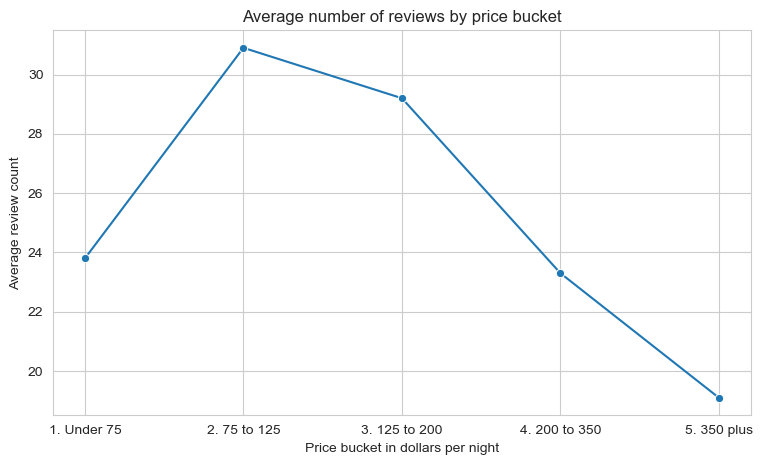

In [7]:
# this one was a surprise. review counts peak in the middle of the market and
# drop at both ends. reviews roughly track bookings, so the cheapest listings
# are not getting booked as much as I would have guessed

plt.figure(figsize=(9, 5))
sns.lineplot(data=reviews, x="price_bucket", y="avg_review_count", marker="o")
plt.title("Average number of reviews by price bucket")
plt.xlabel("Price bucket in dollars per night")
plt.ylabel("Average review count")
plt.show()